In [1]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [2]:
import random
random.seed(0)

In [3]:
import numpy as np
import pandas as pd
loan=pd.read_csv('loan.csv')
loan.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


In [4]:
from sklearn.model_selection import train_test_split
X = loan.drop(['Risk_Flag'],axis=1)
y = loan.Risk_Flag
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [6]:
cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(exclude='object').columns

In [7]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat  = encoder.transform(X_test[cat_cols])

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num  = scaler.transform(X_test[num_cols])

In [9]:
import numpy as np
X_train_final = np.hstack([X_train_num, X_train_cat])
X_test_final  = np.hstack([X_test_num, X_test_cat])

In [10]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=500)
X_train_res, y_train_res = smote.fit_resample(X_train_final, y_train)

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True)

model = Sequential([
    Input(shape=(X_train_res.shape[1],)),
    
    Dense(128, use_bias=False),
    BatchNormalization(),
    Dense(128, activation='relu'),

    Dense(64, use_bias=False),
    BatchNormalization(),
    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
     metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')])

model.fit(
    X_train_res,
    y_train_res,
    batch_size=256,
    epochs=50,
    validation_data=(X_test_final, y_test),
    callbacks=[early_stop])

Epoch 1/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8484 - auc: 0.9189 - loss: 0.3533 - precision: 0.8280 - recall: 0.8794 - val_accuracy: 0.8647 - val_auc: 0.9183 - val_loss: 0.3141 - val_precision: 0.4683 - val_recall: 0.8171
Epoch 2/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9105 - auc: 0.9524 - loss: 0.2456 - precision: 0.8811 - recall: 0.9490 - val_accuracy: 0.8773 - val_auc: 0.9162 - val_loss: 0.3033 - val_precision: 0.4979 - val_recall: 0.7937
Epoch 3/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9203 - auc: 0.9578 - loss: 0.2242 - precision: 0.8897 - recall: 0.9596 - val_accuracy: 0.8783 - val_auc: 0.9175 - val_loss: 0.3092 - val_precision: 0.5003 - val_recall: 0.7930
Epoch 4/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9261 - auc: 0.9615 - loss: 0.2107 - precision: 0.8947 - recall: 0.9658 - val_accuracy: 0.8749 - val_auc: 0.9162 - val_loss: 0.3232 - val_precision: 0.4918 - val_recall: 0.8114


In [18]:
from sklearn.metrics import precision_recall_curve

y_prob = model.predict(X_test_final).ravel()
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
model.evaluate(X_test_final, y_test)

1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 893us/step
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8773 - auc: 0.9162 - loss: 0.3033 - precision: 0.4979 - recall: 0.7937


[0.3033181130886078,
 0.8773214221000671,
 0.9162470102310181,
 0.49785494804382324,
 0.793681800365448]

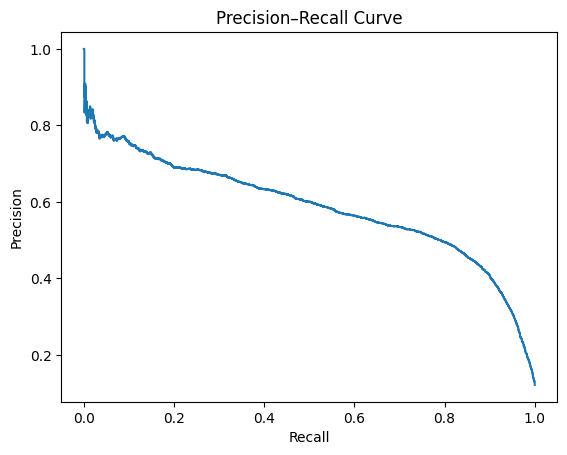

In [20]:
import matplotlib.pyplot as plt

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

In [19]:
import numpy as np

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

best_threshold, f1_scores[best_idx]

(np.float32(0.6299827), np.float64(0.6144053552907998))

In [21]:
BEST_THRESHOLD = 0.63

y_prob = model.predict(X_test_final).ravel()
y_pred_final = (y_prob >= BEST_THRESHOLD).astype(int)

1575/1575 ━━━━━━━━━━━━━━━━━━━━ 1s 934us/step


In [22]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.96      0.91      0.93     44259
           1       0.52      0.75      0.61      6141

    accuracy                           0.89     50400
   macro avg       0.74      0.83      0.77     50400
weighted avg       0.91      0.89      0.89     50400

[[40060  4199]
 [ 1557  4584]]
